In [3]:
import os
import cv2
import math
import heapq
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
import matplotlib.animation as animation
from typing import List, Tuple
from scipy.ndimage import distance_transform_edt
from scipy.ndimage import gaussian_filter


%matplotlib inline


In [4]:
def extract_wall_mask(
    image: np.ndarray,
    lower: np.ndarray = np.array([0, 0, 0]),
    upper: np.ndarray = np.array([50, 50, 50]),
) -> np.ndarray:
    mask = cv2.inRange(image, lower, upper)
    return cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)[1]


def skeletonize_and_thicken(mask: np.ndarray, thickness: int = 3) -> np.ndarray:
    centerline = cv2.ximgproc.thinning(mask)
    if thickness > 1:
        kernel = np.ones((thickness, thickness), np.uint8)
        centerline = cv2.dilate(centerline, kernel, iterations=1)
    return centerline


def detect_doors(
    image: np.ndarray,
    lower: np.ndarray = np.array([0, 0, 245]),
    upper: np.ndarray = np.array([0, 30, 255]),
) -> List[Tuple[int, int]]:
    door_mask = cv2.inRange(image, lower, upper)
    contours, _ = cv2.findContours(door_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    door_location = []
    for cnt in contours:
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])
            door_location.append((cX, cY))
    return door_location


def process_floor_plan(
    image_path: str,
    display_plot: bool = True,
    line_thickness: int = 3,
) -> Tuple[np.ndarray, list[Tuple[int, int]], np.ndarray, np.ndarray]:
    """
    Extracts wall centerline via skeletonization, thickens it, and finds door location.
    Also extracts a filled room mask for interior detection.

    Returns:
        centerline_points: Numpy array of (x, y) wall pixels.
        door_locations: List of (x, y) door centroids.
        visualization_img: BGR image with overlays.
        room_mask: Binary mask (1 = inside room, 0 = outside/walls).
    """

    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    # --- Walls ---
    wall_mask = extract_wall_mask(image)
    centerline_img = skeletonize_and_thicken(wall_mask, line_thickness)

    # Extract wall pixel coordinates
    centerline_points = np.argwhere(centerline_img > 0)[:, ::-1]

    # --- Doors ---
    door_locations = detect_doors(image)

    # --- Room interior mask ---
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    room_mask = np.zeros_like(gray, dtype=np.uint8)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(room_mask, [largest_contour], -1, 1, thickness=cv2.FILLED)

    # --- Visualization ---
    visualization_img = cv2.cvtColor(255 - centerline_img, cv2.COLOR_GRAY2BGR)
    for x, y in door_locations:
        cv2.circle(visualization_img, (x, y), 8, (0, 0, 255), -1)

    if display_plot:
        plt.figure(figsize=(8, 8))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(visualization_img, cv2.COLOR_BGR2RGB))
        plt.title("Wall Centerline + Doors")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(room_mask, cmap="gray")
        plt.title("Room Interior Mask")
        plt.axis("off")
        plt.show()

    return centerline_points, door_locations, visualization_img, room_mask


In [5]:
def find_image_colors(image_path):
    """
    Analyzes an image to find the average color of all distinct colored shapes.
    """
    image = cv2.imread(image_path)
    if image is None:
        print(f"Could not load image: {image_path}")
        return

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Create a mask to exclude black and white areas
    _, thresh = cv2.threshold(
        gray, 240, 255, cv2.THRESH_BINARY_INV
    )  # Invert to get non-white
    black_mask = cv2.inRange(image, np.array([0, 0, 0]), np.array([50, 50, 50]))
    non_black_mask = cv2.bitwise_not(black_mask)

    final_mask = cv2.bitwise_and(thresh, non_black_mask)

    # Find contours of all the colored shapes
    contours, _ = cv2.findContours(
        final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    print(f"--- Analyzing colors in: {image_path} ---")
    if not contours:
        print("No distinct color blobs were found.")
        return

    for i, contour in enumerate(contours):
        # Create a mask for each individual contour
        mask = np.zeros(gray.shape, dtype="uint8")
        cv2.drawContours(mask, [contour], -1, 255, -1)

        # Calculate the average color within that contour's area
        mean_bgr = cv2.mean(image, mask=mask)

        # Format the BGR and RGB values
        b = int(mean_bgr[0])
        g = int(mean_bgr[1])
        r = int(mean_bgr[2])

        print(
            f"Shape #{i + 1}:  Average BGR = ({b}, {g}, {r})  |  RGB = ({r}, {g}, {b})"
        )


In [6]:
def process_multiple_floor_plans(
    folder_path: str, num_results: int = 5, line_thickness: int = 3
):
    """
    Process multiple floor plan images and show them in a dynamic subplot grid.

    Args:
        folder_path: Path containing floor plan images.
        num_results: Number of images to process.
        line_thickness: Wall line thickness for visualization.
    """
    # Collect only .png images
    image_files = [f for f in os.listdir(folder_path) if f.endswith(".png")]
    image_files.sort(key=lambda x: int(os.path.splitext(x)[0]))  # sort numerically

    # Limit to requested number
    image_files = image_files[:num_results]

    # --- Dynamic subplot allocation ---
    cols = math.ceil(math.sqrt(len(image_files)))
    rows = math.ceil(len(image_files) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    for idx, filename in enumerate(image_files):
        image_path = os.path.join(folder_path, filename)

        centerline_points, door_locations, vis_img, room_map = process_floor_plan(
            image_path,
            display_plot=False,  # disable inside function
            line_thickness=line_thickness,
        )

        # Show each result in its subplot
        ax = axes[idx]
        ax.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{filename}\nDoors: {len(door_locations)}")
        ax.axis("off")

    # Hide extra subplot slots if any
    for j in range(len(image_files), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

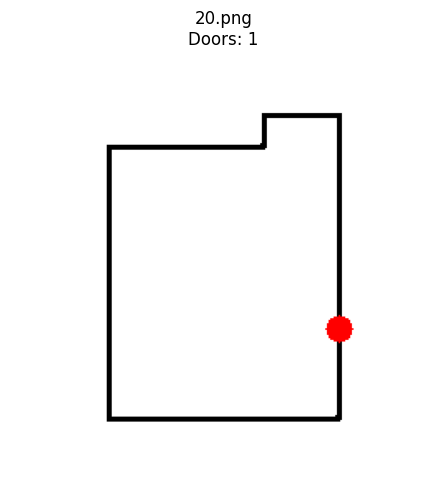

In [7]:
folder = "dataset/2d floor plan"
process_multiple_floor_plans(folder_path=folder, num_results=1, line_thickness=3)

In [8]:
def compute_distance_field(room_mask, door_locations):
    """
    Compute shortest distance (Euclidean-like) from every walkable pixel to nearest door
    using Dijkstra on an 8-neighbor grid. Non-walkable (walls) will have np.inf.
    room_mask: binary (1=walkable interior, 0=wall)
    door_locations: array-like of (x,y) in image coordinates
    Returns: dist_field (float32), same shape as room_mask
    """
    h, w = room_mask.shape
    dist = np.full((h, w), np.inf, dtype=np.float32)
    visited = np.zeros((h, w), dtype=np.uint8)

    # Priority queue holds (distance, y, x)
    pq = []
    # initialize with door cells (clamped to mask)
    for dx, dy in door_locations.astype(int):
        x, y = int(dx), int(dy)
        if x < 0 or x >= w or y < 0 or y >= h:
            continue
        if room_mask[y, x]:
            dist[y, x] = 0.0
            heapq.heappush(pq, (0.0, y, x))
        else:
            # if door lies on wall pixel (rare), try 1-neighborhood
            found = False
            for r in range(1, 4):
                for ox in range(-r, r + 1):
                    for oy in range(-r, r + 1):
                        nx, ny = x + ox, y + oy
                        if 0 <= nx < w and 0 <= ny < h and room_mask[ny, nx]:
                            dist[ny, nx] = 0.0
                            heapq.heappush(pq, (0.0, ny, nx))
                            found = True
                            break
                    if found:
                        break
                if found:
                    break

    # 8-neighbor offsets and costs
    neighbors = [
        (-1, 0, 1.0),
        (1, 0, 1.0),
        (0, -1, 1.0),
        (0, 1, 1.0),
        (-1, -1, np.sqrt(2)),
        (-1, 1, np.sqrt(2)),
        (1, -1, np.sqrt(2)),
        (1, 1, np.sqrt(2)),
    ]

    while pq:
        dcur, y, x = heapq.heappop(pq)
        if visited[y, x]:
            continue
        visited[y, x] = 1

        for dy, dx, cost in neighbors:
            ny, nx = y + dy, x + dx
            if not (0 <= nx < w and 0 <= ny < h):
                continue
            if not room_mask[ny, nx]:
                continue
            nd = dcur + cost
            if nd < dist[ny, nx]:
                dist[ny, nx] = nd
                heapq.heappush(pq, (nd, ny, nx))

    # Non-walkable remain inf
    dist[room_mask == 0] = np.inf
    return dist

In [9]:
def find_nearest_inside(x, y, mask, max_r=6):
    h, w = mask.shape
    xi, yi = int(round(x)), int(round(y))
    if 0 <= xi < w and 0 <= yi < h and mask[yi, xi]:
        return float(xi), float(yi)
    for r in range(1, max_r + 1):
        for dx in range(-r, r + 1):
            for dy in range(-r, r + 1):
                nx, ny = xi + dx, yi + dy
                if 0 <= nx < w and 0 <= ny < h and mask[ny, nx]:
                    return float(nx), float(ny)
    return None

In [10]:
def precompute_fields(dist_field, smooth_sigma=1.0):
    df = dist_field.copy()
    inf_mask = ~np.isfinite(df)
    maxf = np.nanmax(df[np.isfinite(df)]) if np.any(np.isfinite(df)) else 1e6
    df[inf_mask] = maxf * 2.0
    df_blur = gaussian_filter(df.astype(np.float32), sigma=smooth_sigma)
    gy_field, gx_field = np.gradient(df_blur)
    return gx_field.astype(np.float32), gy_field.astype(np.float32)

In [11]:
def update_positions(
    people,
    velocities,
    doors,
    mask,
    dist_field,
    w,
    h,
    speed,
    radius=3.0,
    damping=0.5,
    exit_radius=6.0,
    avoid_radius=10.0,
    avoid_strength=0.6,
    smooth_sigma=1.0,
):
    n = people.shape[0]
    if n == 0:
        return people, velocities

    # --- 0) sanitize inputs (defensive) ---
    people = people.astype(np.float32)
    velocities = velocities.astype(np.float32)

    # --- 1) Remove agents already at exits or outside ---
    alive_mask = np.ones(n, dtype=np.bool_)
    for i in range(n):
        px, py = people[i]
        ix, iy = int(round(px)), int(round(py))

        if not (0 <= ix < w and 0 <= iy < h and mask[iy, ix]):
            v = find_nearest_inside(px, py, mask, max_r=8)
            if v is None:
                alive_mask[i] = False
                continue
            people[i] = v
            px, py = people[i]

        for d in doors:
            ddx, ddy = d[0] - px, d[1] - py
            if ddx * ddx + ddy * ddy < exit_radius * exit_radius:
                alive_mask[i] = False
                break

    people = people[alive_mask]
    velocities = velocities[alive_mask]
    n = people.shape[0]
    if n == 0:
        return people, velocities

    # --- 2) Prepare smoothed gradient of distance field (compute once) ---
    # Use cv2.GaussianBlur if available (we used cv2 elsewhere); otherwise fallback to numpy smoothing
    try:
        # dist_field may contain np.inf for walls — replace inf with a large number before smoothing
        df = dist_field.copy()
        inf_mask = ~np.isfinite(df)
        maxf = np.nanmax(df[np.isfinite(df)]) if np.any(np.isfinite(df)) else 1e6
        df[inf_mask] = maxf * 2.0
        # cv2.GaussianBlur expects a float32 / float64 image
        df_blur = cv2.GaussianBlur(
            df.astype(np.float32), (0, 0), sigmaX=smooth_sigma, sigmaY=smooth_sigma
        )
    except Exception:
        # fallback simple smoothing with a small mean filter
        kernel = np.ones((3, 3), dtype=np.float32) / 9.0
        df = dist_field.copy()
        df[np.logical_not(np.isfinite(df))] = (
            np.nanmax(df[np.isfinite(df)]) if np.any(np.isfinite(df)) else 1e6
        )
        from scipy.signal import convolve2d

        df_blur = convolve2d(df, kernel, mode="same", boundary="symm")

    # compute gradients (dx, dy) using numpy.gradient (dy, dx)
    gy_field, gx_field = np.gradient(df_blur)  # gy_field: d/drow, gx_field: d/dcol

    # --- 3) Goal following + local avoidance (per-agent) ---
    new_vel = velocities.copy()
    for i in range(n):
        px, py = people[i]
        # clamp sample coords
        ix = int(np.clip(int(round(px)), 1, w - 2))
        iy = int(np.clip(int(round(py)), 1, h - 2))

        # if agent on wall, snap inside quickly
        if not mask[iy, ix]:
            v = find_nearest_inside(px, py, mask, max_r=6)
            if v is not None:
                people[i] = v
                px, py = people[i]
                ix = int(np.clip(int(round(px)), 1, w - 2))
                iy = int(np.clip(int(round(py)), 1, h - 2))
            else:
                # can't recover this agent
                new_vel[i] = 0.0
                continue

        # read smoothed gradient at agent position
        gx = gx_field[iy, ix]
        gy = gy_field[iy, ix]

        # navigation vector points toward decreasing distance (negative gradient)
        nav_x = -gx
        nav_y = -gy
        nav_norm = np.hypot(nav_x, nav_y)

        if nav_norm < 1e-6:
            # fallback: point toward nearest door + small tangential nudge to slide along wall
            # choose nearest door
            best_d_idx = 0
            best_d_dist = 1e12
            for di, d in enumerate(doors):
                ddx, ddy = d[0] - px, d[1] - py
                ddist = ddx * ddx + ddy * ddy
                if ddist < best_d_dist:
                    best_d_dist = ddist
                    best_d_idx = di
            ddx = doors[best_d_idx, 0] - px
            ddy = doors[best_d_idx, 1] - py
            dnorm = np.hypot(ddx, ddy) + 1e-6
            door_dir_x = ddx / dnorm
            door_dir_y = ddy / dnorm

            # small tangential component: perpendicular to door_dir (choose sign by local mask occupancy)
            tang_x, tang_y = -door_dir_y, door_dir_x

            # check which tangential direction leads to interior (prefer that)
            test_px = px + tang_x * 2.0
            test_py = py + tang_y * 2.0
            tix = int(np.clip(int(round(test_px)), 0, w - 1))
            tiy = int(np.clip(int(round(test_py)), 0, h - 1))
            if not (0 <= tix < w and 0 <= tiy < h and mask[tiy, tix]):
                # flip tangent
                tang_x, tang_y = -tang_x, -tang_y

            # combined fallback direction
            mix = 0.85  # mostly toward door
            nav_x = mix * door_dir_x + (1 - mix) * tang_x * 0.6
            nav_y = mix * door_dir_y + (1 - mix) * tang_y * 0.6
            nav_norm = np.hypot(nav_x, nav_y) + 1e-9

        # goal velocity from nav vector
        goal_vx = (nav_x / (nav_norm + 1e-12)) * speed
        goal_vy = (nav_y / (nav_norm + 1e-12)) * speed

        # local avoidance (repulsion) from neighbors
        rx = ry = 0.0
        for j in range(n):
            if j == i:
                continue
            dx_j = people[j, 0] - people[i, 0]
            dy_j = people[j, 1] - people[i, 1]
            d_ij = np.hypot(dx_j, dy_j)
            if 1e-6 < d_ij < avoid_radius:
                repulse = (avoid_radius - d_ij) / avoid_radius
                rx -= (dx_j / d_ij) * repulse
                ry -= (dy_j / d_ij) * repulse

        combined_vx = goal_vx + rx * avoid_strength
        combined_vy = goal_vy + ry * avoid_strength

        # smooth velocity update (inertia)
        alpha = 0.6
        new_vel[i, 0] = (1 - alpha) * velocities[i, 0] + alpha * combined_vx
        new_vel[i, 1] = (1 - alpha) * velocities[i, 1] + alpha * combined_vy

        # clamp speed
        sp = np.hypot(new_vel[i, 0], new_vel[i, 1]) + 1e-12
        if sp > speed:
            new_vel[i] = (new_vel[i] / sp) * speed

        # --- unsticking nudge if nearly zero velocity ---
        if abs(new_vel[i, 0]) < 1e-3 and abs(new_vel[i, 1]) < 1e-3:
            theta = np.random.rand() * 2.0 * np.pi
            new_vel[i, 0] = np.cos(theta) * 0.5 * speed
            new_vel[i, 1] = np.sin(theta) * 0.5 * speed

    # --- 4) Propose positions and sanitize immediately ---
    new_pos = people + new_vel
    new_pos = np.nan_to_num(new_pos, nan=0.0, posinf=0.0, neginf=0.0)
    new_vel = np.nan_to_num(new_vel, nan=0.0, posinf=0.0, neginf=0.0)

    # --- 5) Keep inside mask (try fraction steps) ---
    for i in range(n):
        nx, ny = new_pos[i]
        ix = int(np.clip(int(round(nx)), 0, w - 1))
        iy = int(np.clip(int(round(ny)), 0, h - 1))
        if not mask[iy, ix]:
            moved = False
            for s in [0.9, 0.75, 0.5, 0.25]:
                tx = people[i, 0] + new_vel[i, 0] * s
                ty = people[i, 1] + new_vel[i, 1] * s
                ix2 = int(np.clip(int(round(tx)), 0, w - 1))
                iy2 = int(np.clip(int(round(ty)), 0, h - 1))
                if mask[iy2, ix2]:
                    new_pos[i, 0], new_pos[i, 1] = tx, ty
                    moved = True
                    break
            if not moved:
                v = find_nearest_inside(people[i, 0], people[i, 1], mask, max_r=6)
                if v is not None:
                    new_pos[i, 0], new_pos[i, 1] = v
                new_vel[i] *= 0.0

    # --- 6) Inelastic collisions & push-apart (safe)
    for i in range(n):
        for j in range(i + 1, n):
            dx = new_pos[j, 0] - new_pos[i, 0]
            dy = new_pos[j, 1] - new_pos[i, 1]
            dist = np.hypot(dx, dy)
            if dist < 1e-6:
                jitter = 1e-3
                new_pos[i, 0] -= jitter
                new_pos[j, 0] += jitter
                new_pos[i, 1] -= jitter
                new_pos[j, 1] += jitter
                continue
            if dist < 2.0 * radius:
                overlap = 0.5 * (2.0 * radius - dist)
                nx = dx / dist
                ny = dy / dist
                new_pos[i, 0] -= nx * overlap
                new_pos[i, 1] -= ny * overlap
                new_pos[j, 0] += nx * overlap
                new_pos[j, 1] += ny * overlap
                v_avg = 0.5 * (new_vel[i] + new_vel[j]) * damping
                new_vel[i] = v_avg
                new_vel[j] = v_avg

    # sanitize again
    new_pos = np.nan_to_num(new_pos, nan=0.0, posinf=0.0, neginf=0.0)
    new_vel = np.nan_to_num(new_vel, nan=0.0, posinf=0.0, neginf=0.0)

    # --- 7) Final inside check + exit removal ---
    survivors_pos = []
    survivors_vel = []
    for i in range(n):
        px, py = new_pos[i]
        ix = int(np.clip(int(round(px)), 0, w - 1))
        iy = int(np.clip(int(round(py)), 0, h - 1))
        if not mask[iy, ix]:
            v = find_nearest_inside(px, py, mask, max_r=6)
            if v is None:
                continue
            px, py = v

        exited = any(
            (d[0] - px) ** 2 + (d[1] - py) ** 2 < exit_radius**2 for d in doors
        )
        if exited:
            continue

        survivors_pos.append((float(px), float(py)))
        survivors_vel.append((float(new_vel[i, 0]), float(new_vel[i, 1])))

    if len(survivors_pos) == 0:
        return np.zeros((0, 2), dtype=np.float32), np.zeros((0, 2), dtype=np.float32)

    return np.array(survivors_pos, dtype=np.float32), np.array(
        survivors_vel, dtype=np.float32
    )


In [12]:
def simulate_crowd(
    image_path,
    num_people=100,
    steps=400,
    speed=2.0,
    radius=3.0,
    damping=0.6,
    exit_radius=6.0,
):
    # extract geometry (uses your process_floor_plan)
    centerline_points, door_locations, vis_img, room_mask = process_floor_plan(
        image_path, display_plot=False, line_thickness=3
    )

    if not door_locations:
        raise ValueError("No doors detected in the floor plan!")

    doors = np.array(door_locations, dtype=np.float32)
    h, w = room_mask.shape

    # compute distance field once
    dist_field = compute_distance_field(room_mask, doors)

    # init people INSIDE the room
    people = np.zeros((num_people, 2), dtype=np.float32)
    for i in range(num_people):
        # sample until inside mask
        attempt = 0
        while True:
            x = np.random.rand() * (w - 1)
            y = np.random.rand() * (h - 1)
            if room_mask[int(round(y)), int(round(x))]:
                people[i, 0] = x
                people[i, 1] = y
                break
            attempt += 1
            if attempt > 500:
                raise RuntimeError(
                    "Could not place people inside room - check room_mask or num_people"
                )

    # initial velocities zero
    velocities = np.zeros_like(people)

    # Matplotlib animation
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(room_mask, cmap="gray")
    scat = ax.scatter(people[:, 0], people[:, 1], c="blue", s=20, label="People")
    ax.scatter(doors[:, 0], doors[:, 1], c="red", s=80, marker="x", label="Doors")
    ax.legend(loc="upper right")
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)  # flip y for image coords

    def update(frame):
        nonlocal people, velocities, dist_field
        if people.shape[0] == 0:
            return (scat,)

        people, velocities = update_positions(
            people,
            velocities,
            doors,
            room_mask,
            dist_field,
            w,
            h,
            speed,
            radius=radius,
            damping=damping,
            exit_radius=exit_radius,
            avoid_radius=10.0,
            avoid_strength=0.8,
        )

        if people.shape[0] == 0:
            scat.set_offsets(np.zeros((0, 2)))
            return (scat,)

        scat.set_offsets(people)
        return (scat,)

    ani = animation.FuncAnimation(
        fig, update, frames=steps, interval=50, blit=True, repeat=False
    )
    plt.close(fig)
    return HTML(ani.to_html5_video())

In [13]:
# simulate_crowd("dataset/2d floor plan 2/80647.png", num_people=500, speed=1.5)

In [14]:
def normalize_vector_field(U, V, eps=1e-6):
    """
    Normalize vector field to unit length for quiver visualization.
    Returns normalized (U, V) and magnitude.
    """
    magnitude = np.sqrt(U**2 + V**2) + eps
    U_norm = U / magnitude
    V_norm = V / magnitude
    return U_norm, V_norm, magnitude


def visualize_gradient_field(
    image, room_mask, dist_field, gx_field, gy_field, step=10, scale=40
):
    h, w = room_mask.shape
    Y, X = np.mgrid[0:h:step, 0:w:step]

    # mask valid positions
    mask_valid = room_mask[Y, X] > 0

    # negative gradient points *towards* the door
    U = -gx_field[Y, X]
    V = -gy_field[Y, X]

    # normalize vector field
    U_norm, V_norm, mag = normalize_vector_field(U, V)

    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.imshow(
        np.where(np.isfinite(dist_field), dist_field, np.nan), cmap="viridis", alpha=0.5
    )  # overlay distance heatmap

    # use normalized vectors for direction, magnitude for coloring
    plt.quiver(
        X[mask_valid],
        Y[mask_valid],
        U_norm[mask_valid],
        V_norm[mask_valid],
        mag[mask_valid],  # color encodes magnitude
        cmap="plasma",
        scale=scale,
        width=0.003,
    )

    plt.colorbar(label="Gradient Magnitude")
    plt.title("Normalized Gradient Field Towards Doors")
    plt.axis("off")
    plt.show()


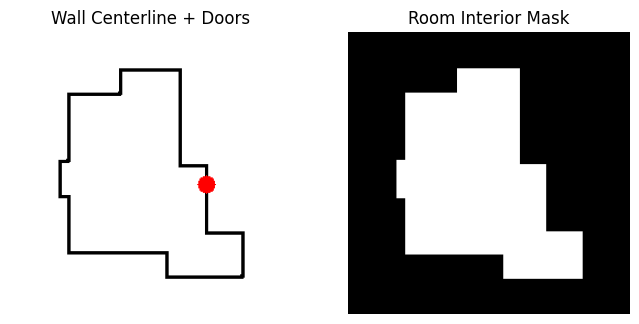

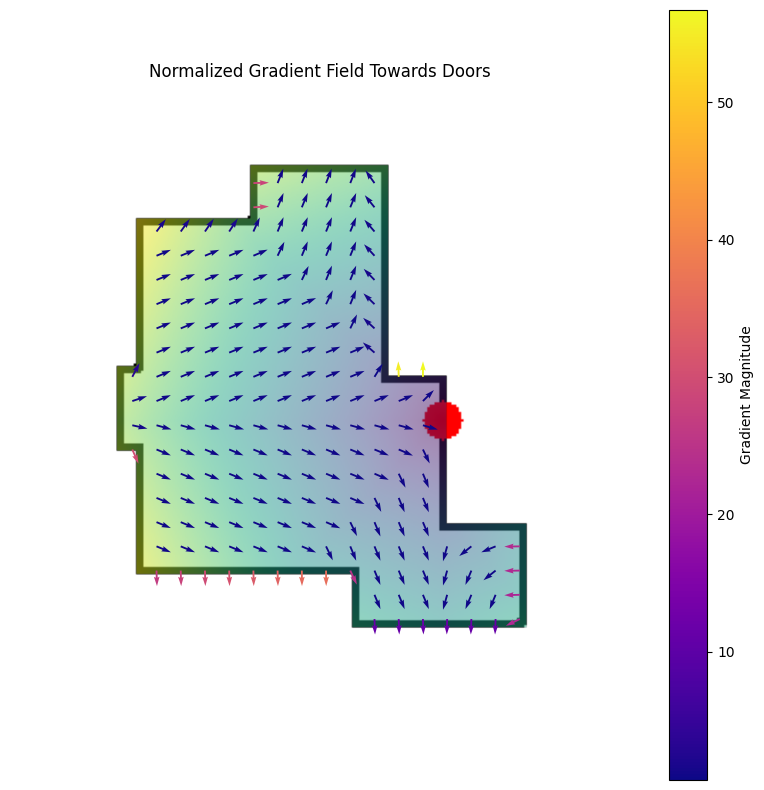

In [15]:
centerline_points, door_locations, visualization_img, room_mask = process_floor_plan(
    "dataset/2d floor plan 2/80647.png"
)

dist_field = compute_distance_field(room_mask, np.array(door_locations))
gx_field, gy_field = precompute_fields(dist_field, smooth_sigma=2.0)

image = cv2.imread("maze.png")
visualize_gradient_field(
    visualization_img, room_mask, dist_field, gx_field, gy_field, step=10
)


In [40]:
def simulate_crowd_with_metrics(
    image_path,
    num_people=100,
    steps=400,
    speed=2.0,
    radius=3.0,
    damping=0.6,
    exit_radius=6.0,
    log_every=1,
):
    # --- Setup ---
    centerline_points, door_locations, vis_img, room_mask = process_floor_plan(
        image_path, display_plot=False, line_thickness=3
    )
    if not door_locations:
        raise ValueError("No doors detected in the floor plan!")

    doors = np.array(door_locations, dtype=np.float32)
    h, w = room_mask.shape
    dist_field = compute_distance_field(room_mask, doors)

    # Init people inside room
    people = np.zeros((num_people, 2), dtype=np.float32)
    for i in range(num_people):
        while True:
            x, y = np.random.rand() * (w - 1), np.random.rand() * (h - 1)
            if room_mask[int(y), int(x)]:
                people[i] = (x, y)
                break
    velocities = np.zeros_like(people)

    # --- Logging ---
    exit_times = np.full(num_people, np.nan)
    spawn_time = np.zeros(num_people)
    log = {
        "step": [],
        "num_alive": [],
        "num_exited": [],
        "exits_per_door": [],
        "collisions": [],
        "queue_lengths": [],
        "density": [],
    }

    # --- Matplotlib animation ---
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(room_mask, cmap="gray")
    scat = ax.scatter(people[:, 0], people[:, 1], c="blue", s=20, label="People")
    ax.scatter(doors[:, 0], doors[:, 1], c="red", s=80, marker="x", label="Doors")
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    ax.legend(loc="upper right")

    def update(frame):
        nonlocal people, velocities

        if people.shape[0] == 0:
            scat.set_offsets(np.zeros((0, 2)))
            return (scat,)

        # --- Update positions ---
        people, velocities = update_positions(
            people,
            velocities,
            doors,
            room_mask,
            dist_field,
            w,
            h,
            speed,
            radius=radius,
            damping=damping,
            exit_radius=exit_radius,
        )

        # --- Logging metrics ---
        after_n = len(people)
        num_exited = num_people - after_n
        exited_indices = np.where(np.isnan(exit_times))[0][:num_exited]
        exit_times[exited_indices] = frame

        collisions = 0
        if after_n > 1:
            dists = np.linalg.norm(people[:, None, :] - people[None, :, :], axis=-1)
            collisions = np.sum((dists < 2 * radius) & (dists > 0)) // 2

        queue_lengths = [
            np.sum(np.hypot(people[:, 0] - dx, people[:, 1] - dy) < 3 * radius)
            for dx, dy in doors
        ]
        mean_density = (
            np.mean(
                [
                    np.sum(
                        np.hypot(
                            people[:, 0] - people[i, 0], people[:, 1] - people[i, 1]
                        )
                        < 2 * radius
                    )
                    for i in range(after_n)
                ]
            )
            if after_n > 0
            else 0
        )

        if frame % log_every == 0:
            log["step"].append(frame)
            log["num_alive"].append(after_n)
            log["num_exited"].append(np.sum(~np.isnan(exit_times)))
            log["exits_per_door"].append(queue_lengths)
            log["collisions"].append(collisions)
            log["queue_lengths"].append(queue_lengths)
            log["density"].append(mean_density)

        scat.set_offsets(people)
        return (scat,)

    ani = animation.FuncAnimation(
        fig, update, frames=steps, interval=50, blit=True, repeat=False
    )
    plt.close(fig)

    # --- Compute metrics ---
    travel_times = exit_times - spawn_time
    metrics = {
        "evacuation_time": np.nanmax(exit_times),
        "mean_travel_time": np.nanmean(travel_times),
        "median_travel_time": np.nanmedian(travel_times),
        "var_travel_time": np.nanvar(travel_times),
        "throughput_curve": log["num_exited"],
        "max_queue_length": np.max(log["queue_lengths"]),
        "mean_density": np.mean(log["density"]),
        "collision_count": np.sum(log["collisions"]),
    }

    return metrics, log, HTML(ani.to_html5_video())

In [41]:
def plot_crowd_metrics(metrics, logs):
    steps = logs["step"]
    num_alive = logs["num_alive"]
    num_exited = logs["num_exited"]
    collisions = logs["collisions"]
    density = logs["density"]

    # Handle per-door data
    exits_per_door = list(zip(*logs["exits_per_door"]))
    queues_per_door = list(zip(*logs["queue_lengths"]))
    num_doors = len(exits_per_door)

    # --- Create figure with subplots ---
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    axes = axes.flatten()  # Flatten to index easily

    # 1. Throughput curve
    axes[0].plot(steps, num_exited, label="Cumulative Exits", color="blue")
    axes[0].set_title("Throughput Curve")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("People Exited")
    axes[0].legend()
    axes[0].grid(True)

    # 2. Alive vs Exited
    axes[1].plot(steps, num_alive, label="Alive", color="orange")
    axes[1].plot(steps, num_exited, label="Exited", color="blue")
    axes[1].set_title("Alive vs Exited Over Time")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Number of People")
    axes[1].legend()
    axes[1].grid(True)

    # 3. Per-door exits
    for i, values in enumerate(exits_per_door):
        axes[2].plot(steps, values, label=f"Door {i}")
    axes[2].set_title("Exits per Door")
    axes[2].set_xlabel("Step")
    axes[2].set_ylabel("Cumulative Exits")
    axes[2].legend()
    axes[2].grid(True)

    # 4. Queue lengths per door
    for i, values in enumerate(queues_per_door):
        axes[3].plot(steps, values, label=f"Door {i}")
    axes[3].set_title("Queue Lengths per Door")
    axes[3].set_xlabel("Step")
    axes[3].set_ylabel("Queue Length")
    axes[3].legend()
    axes[3].grid(True)

    # 5. Collisions over time
    axes[4].plot(steps, collisions, color="red")
    axes[4].set_title("Collisions Over Time")
    axes[4].set_xlabel("Step")
    axes[4].set_ylabel("Collisions")
    axes[4].grid(True)

    # 6. Density evolution
    axes[5].plot(steps, density, color="green")
    axes[5].set_title("Density Over Time")
    axes[5].set_xlabel("Step")
    axes[5].set_ylabel("Density (people/unit area)")
    axes[5].grid(True)

    plt.tight_layout()
    plt.show()


# Usage
# plot_crowd_metrics_subplots(metrics, logs)


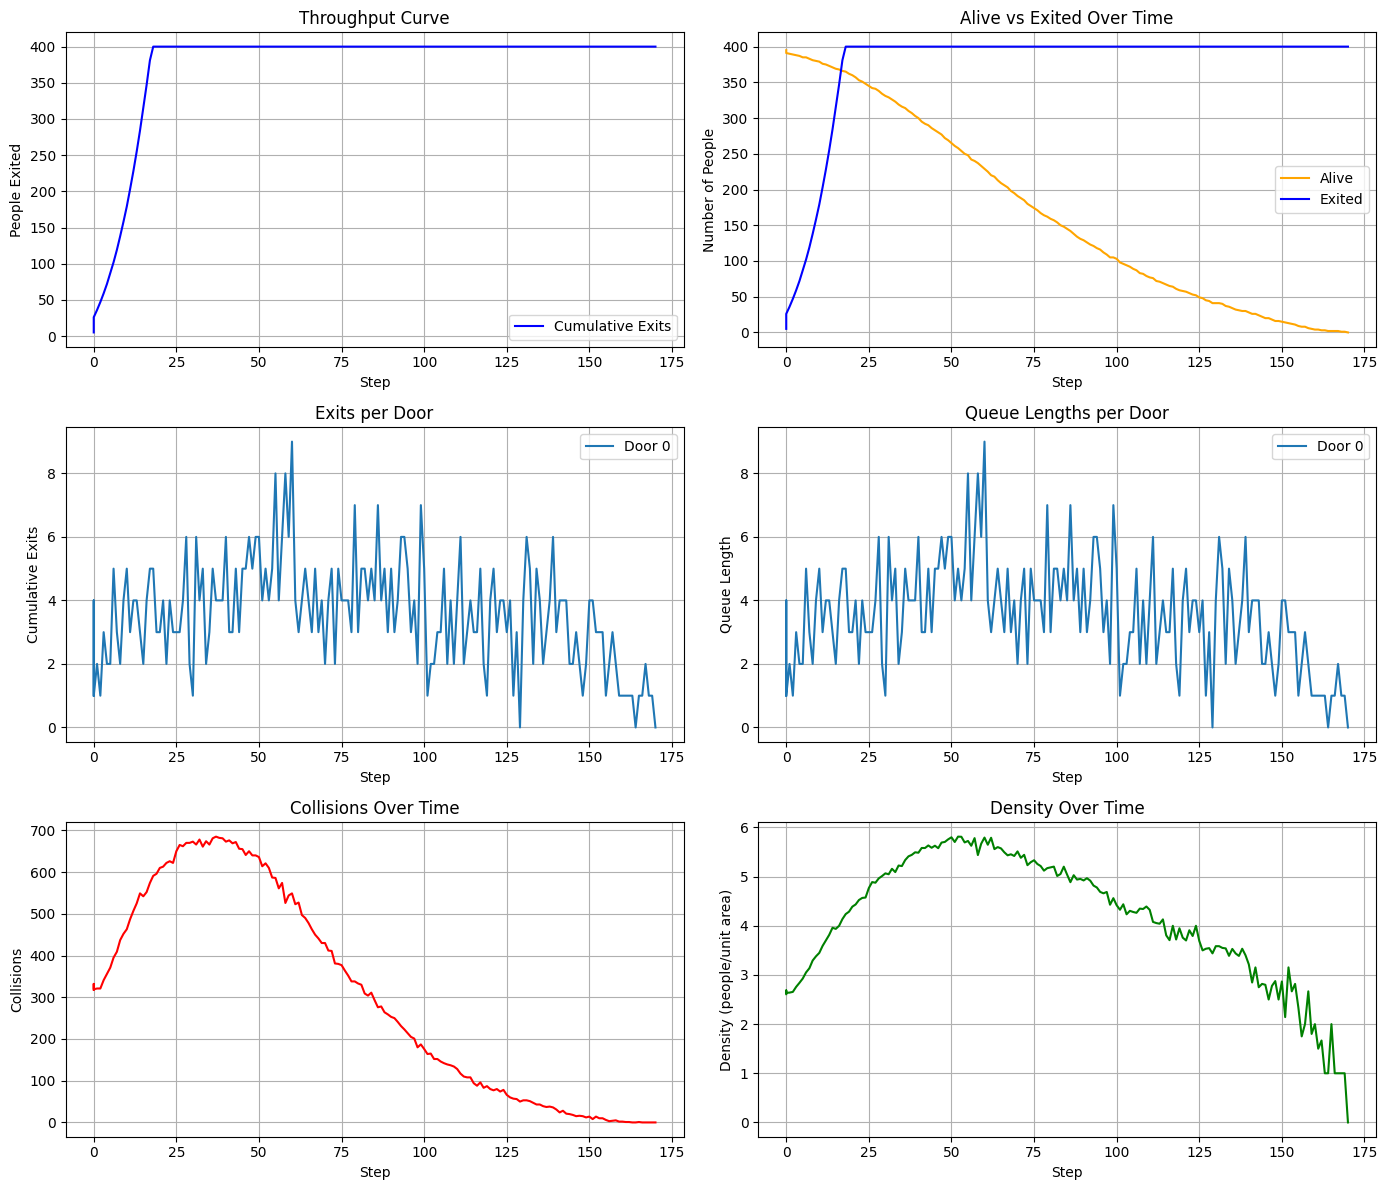

In [48]:
metrics, logs, video = simulate_crowd_with_metrics(
    "dataset/2d floor plan/10939.png", num_people=400, steps=175
)
plot_crowd_metrics(metrics, logs)
video
